In [1]:
!pip install Yfinance


--- Strategy Performance ---
CAGR: 11.07%
Annual Volatility: 14.69%
Sharpe Ratio: 0.62
Max Drawdown: -15.99%

--- Benchmark (SPY) Performance ---
CAGR: 14.16%
Annual Volatility: 15.14%
Sharpe Ratio: 0.80
Max Drawdown: -23.93%

--- Last 6 months of sector picks ---
2026-04: ['XLE', 'XLB', 'XLU']
2026-05: ['XLE', 'XLB', 'XLI']
2026-06: ['XLK', 'XLE', 'XLB']
2026-07: ['XLK', 'XLE', 'XLI']
2026-08: ['XLK', 'XLE', 'XLRE']
2026-09: ['XLK', 'XLE', 'XLF']

Saved chart to backtest_results.png


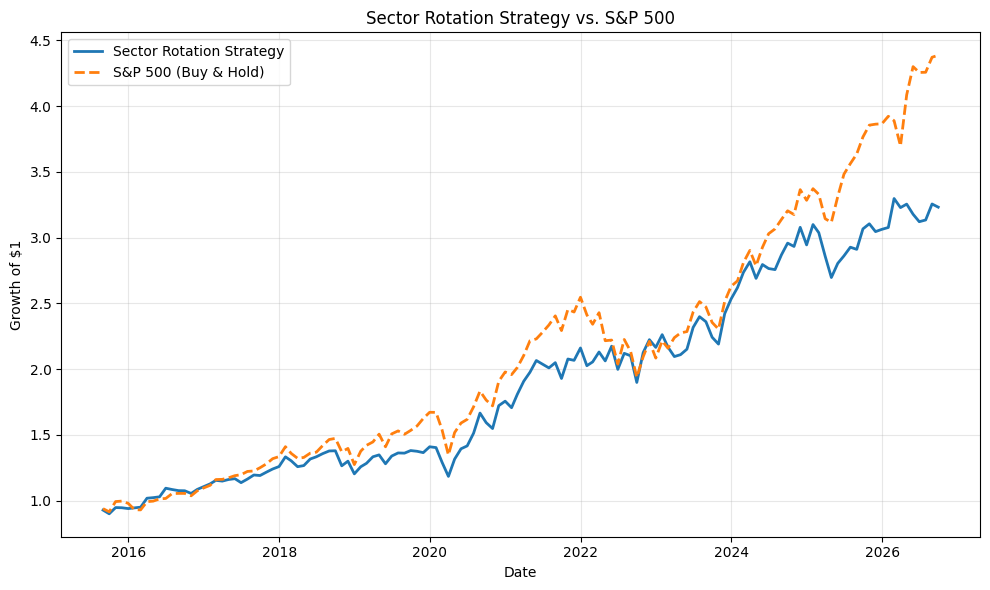

In [2]:
"""
Sector Rotation Strategy
=========================
Thesis: different S&P 500 sectors outperform at different points in the
economic cycle (e.g. tech/discretionary lead in expansions, staples/utilities
lead in slowdowns). This strategy ranks the 11 SPDR sector ETFs each month
by trailing momentum and rotates into the strongest sectors, on the idea
that relative strength persists in the short-to-medium term.

Author: Yajvin Jain
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
SECTOR_ETFS = [
    "XLK",  # Technology
    "XLE",  # Energy
    "XLV",  # Health Care
    "XLF",  # Financials
    "XLY",  # Consumer Discretionary
    "XLP",  # Consumer Staples
    "XLI",  # Industrials
    "XLU",  # Utilities
    "XLB",  # Materials
    "XLRE", # Real Estate
    "XLC",  # Communication Services
]
BENCHMARK = "SPY"          # S&P 500 buy-and-hold, our comparison point
START_DATE = "2015-01-01"
LOOKBACK_MONTHS = 6        # how far back we look to measure "momentum"
TOP_N = 3                  # how many sectors we hold each month
RISK_FREE_RATE = 0.02      # rough annual risk-free rate, for Sharpe ratio


# ---------------------------------------------------------------------------
# STEP 1: DOWNLOAD DATA
# ---------------------------------------------------------------------------
def download_prices():
    tickers = SECTOR_ETFS + [BENCHMARK]
    print(f"Downloading data for {len(tickers)} tickers since {START_DATE}...")
    data = yf.download(tickers, start=START_DATE, auto_adjust=True, progress=False)["Close"]
    data = data.dropna(how="all")
    return data


# ---------------------------------------------------------------------------
# STEP 2: BUILD MONTHLY SIGNALS
# ---------------------------------------------------------------------------
def build_monthly_data(daily_prices):
    monthly_prices = daily_prices.resample("ME").last()
    momentum = monthly_prices[SECTOR_ETFS].pct_change(LOOKBACK_MONTHS)
    return monthly_prices, momentum


# ---------------------------------------------------------------------------
# STEP 3: RUN THE STRATEGY (BACKTEST)
# ---------------------------------------------------------------------------
def backtest(monthly_prices, momentum):
    """
    Each month: look at trailing momentum, pick the TOP_N strongest sectors,
    hold them equally-weighted for the NEXT month, then re-rank and repeat.
    """
    monthly_returns = monthly_prices[SECTOR_ETFS].pct_change()
    strat_returns = []
    dates = []
    holdings_log = []

    for i in range(LOOKBACK_MONTHS, len(monthly_prices) - 1):
        scores = momentum.iloc[i].dropna()
        if len(scores) < TOP_N:
            continue
        top_sectors = scores.sort_values(ascending=False).head(TOP_N).index.tolist()
        next_month_return = monthly_returns.iloc[i + 1][top_sectors].mean()

        strat_returns.append(next_month_return)
        dates.append(monthly_prices.index[i + 1])
        holdings_log.append((monthly_prices.index[i + 1].strftime("%Y-%m"), top_sectors))

    strat_series = pd.Series(strat_returns, index=dates, name="Strategy")
    benchmark_series = monthly_prices[BENCHMARK].pct_change().reindex(strat_series.index)
    benchmark_series.name = "Benchmark (SPY)"

    return strat_series, benchmark_series, holdings_log


# ---------------------------------------------------------------------------
# STEP 4: PERFORMANCE METRICS
# ---------------------------------------------------------------------------
def performance_metrics(returns, freq=12):
    returns = returns.dropna()
    n_years = len(returns) / freq
    cagr = (1 + returns).prod() ** (1 / n_years) - 1
    vol = returns.std() * np.sqrt(freq)
    sharpe = (cagr - RISK_FREE_RATE) / vol if vol != 0 else np.nan
    cum = (1 + returns).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    return {
        "CAGR": f"{cagr:.2%}",
        "Annual Volatility": f"{vol:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Max Drawdown": f"{max_dd:.2%}",
    }


# ---------------------------------------------------------------------------
# STEP 5: PLOT RESULTS
# ---------------------------------------------------------------------------
def plot_results(strat_returns, benchmark_returns):
    cum_strat = (1 + strat_returns).cumprod()
    cum_bench = (1 + benchmark_returns).cumprod()

    plt.figure(figsize=(10, 6))
    plt.plot(cum_strat.index, cum_strat.values, label="Sector Rotation Strategy", linewidth=2)
    plt.plot(cum_bench.index, cum_bench.values, label="S&P 500 (Buy & Hold)", linewidth=2, linestyle="--")
    plt.title("Sector Rotation Strategy vs. S&P 500")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("backtest_results.png", dpi=150)
    print("\nSaved chart to backtest_results.png")


# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------
def main():
    daily_prices = download_prices()
    monthly_prices, momentum = build_monthly_data(daily_prices)
    strat_returns, benchmark_returns, holdings_log = backtest(monthly_prices, momentum)

    print("\n--- Strategy Performance ---")
    for k, v in performance_metrics(strat_returns).items():
        print(f"{k}: {v}")

    print("\n--- Benchmark (SPY) Performance ---")
    for k, v in performance_metrics(benchmark_returns).items():
        print(f"{k}: {v}")

    print("\n--- Last 6 months of sector picks ---")
    for date, sectors in holdings_log[-6:]:
        print(f"{date}: {sectors}")

    plot_results(strat_returns, benchmark_returns)


if __name__ == "__main__":
    main()
